In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import scanpy as sc
import anndata as ad
import skimage as skimage

In [11]:
PROJECT_ROOT = Path.cwd().resolve().parent.parent

output_dir = PROJECT_ROOT / "results" / "UPPL1541"
output_dir.mkdir(parents=True, exist_ok=True)

UMAP_STYLE = {
    "legend_loc": "on data",
    "legend_fontsize": 9,
    "legend_fontweight": "semibold",
    "legend_fontoutline": 2,
    "size": 20,
    "alpha": 0.85,
    "marker": "o",
    "add_outline": True,
    "outline_width": (0.2, 0.03),
    "palette": "Set1",
    "ncols": 2,
    "wspace": 0.3,
}

In [4]:
adata = sc.read_h5ad(PROJECT_ROOT / "data" / "processed" / "uppl1541_processed_unlabeled.h5ad")

adata_leukocytes = adata[adata.obs["leukocyte_cluster_call"] == "Leukocyte", :].copy()

In [5]:
# keys: cell types or populations, values: lists of marker genes

broad_cell_type_markers = {
    "Tumor_Urothelial": ["Epcam", "Krt8", "Krt18", "Krt19", "Upk1a", "Upk2", "Gata3", "Foxa1"],
    "T_Cells": ["Cd3d", "Cd3e", "Cd3g", "Trac", "Lck"],
    "B_Cells": ["Cd79a", "Cd79b", "Ms4a1", "Cd74", "Cd37"],
    "Macrophages": ["C1qa", "C1qb", "C1qc", "Csf1r", "Adgre1", "Fcgr1", "Mertk"],
    "Monocytes": ["Ly6c2", "Ccr2", "Plac8", "Lst1", "Lyz2"],
    "Neutrophils": ["Ly6g", "Csf3r", "Retnlg", "S100a8", "S100a9"],
    "Endothelial": ["Pecam1", "Cdh5", "Kdr", "Emcn"],
    "Fibroblasts": ["Col1a1", "Col1a2", "Dcn", "Pdgfra"],
    "NK_Cells": ["Ncr1", "Klrb1c", "Nkg7", "Prf1", "Gzmb"]
}

immune_cell_markers = {
    "Neutrophils": [
        "Ly6g", "Csf3r", "Retnlg", "Ngp",
        "Camp", "S100a8", "S100a9", "Mmp8"
],

    "Macrophages": [
        "C1qa", "C1qb", "C1qc", "Mertk",
        "Fcgr1", "Adgre1", "Apoe", "Ms4a7",
        "Csf1r", "Cd68"
    ],

    "Monocytes": [
        "Ly6c2", "Ccr2", "Plac8", "Sell",
        "S100a8", "S100a9", "Chil3", "Fn1"
    ],

    "B_Cells": [
        "Cd79a", "Cd79b", "Ms4a1",
        "Cd22", "Bank1", "Pax5", "Ebf1"
    ],

    "Pan_T_Cells": [
        "Cd3d", "Cd3e", "Cd3g",
        "Trac", "Lck", "Lat"
    ],

    "CD4_T_Cells": [
        "Cd3d", "Cd3e", "Trac",
        "Cd4", "Il7r", "Ccr7",
        "Tcf7", "Lef1", "Mal"
    ],

    "CD8_T_Cells": [
        "Cd3d", "Cd3e", "Trac",
        "Cd8a", "Cd8b1",
        "Ccl5", "Gzmk"
    ],

    "NK_Cells": [
        "Ncr1", "Klrk1", "Klrb1c",
        "Nkg7", "Prf1", "Gzmb", "Tyrobp"
    ]
}

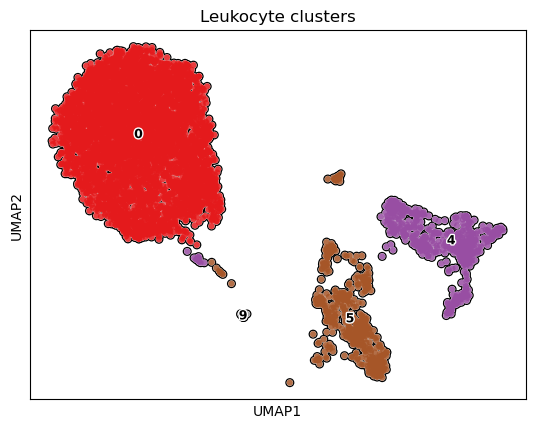

In [7]:
sc.pl.umap(adata_leukocytes, 
           color="leiden",
           **UMAP_STYLE,
           title="Leukocyte clusters")

categories: 0, 4, 5, etc.
var_group_labels: Neutrophils, Macrophages, Monocytes, etc.


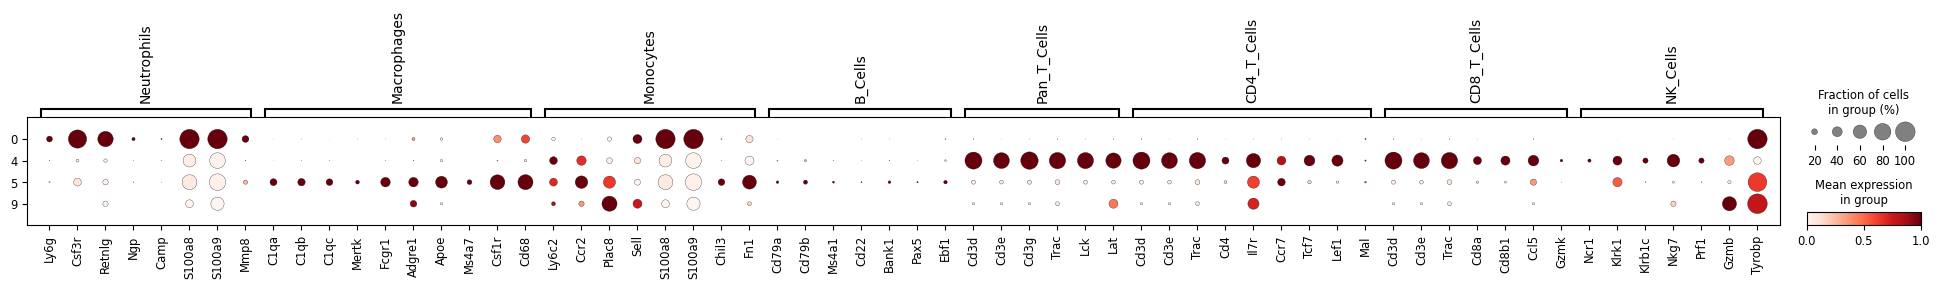

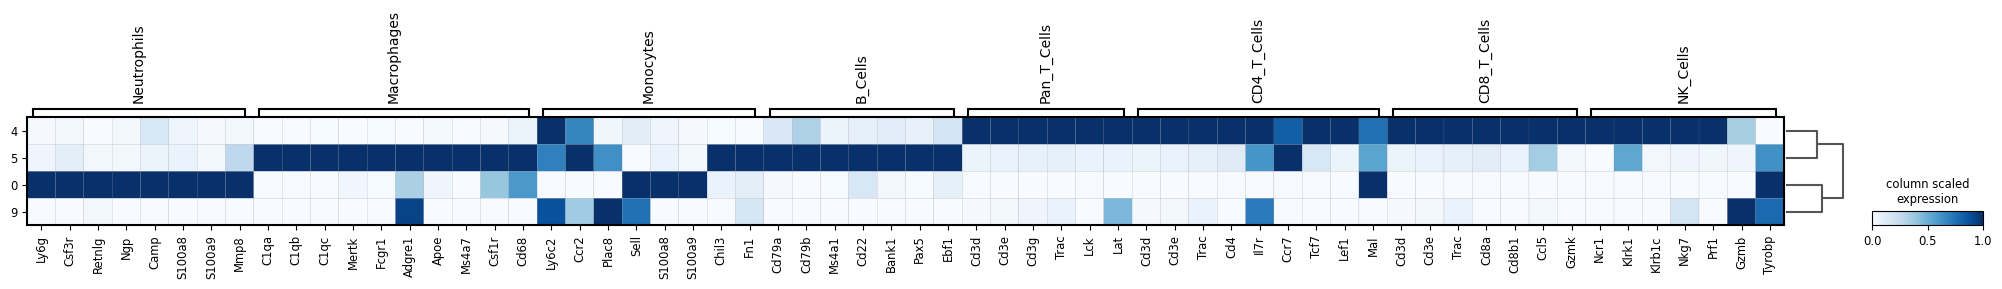

In [16]:
dp = sc.pl.dotplot(adata_leukocytes, immune_cell_markers, groupby="leiden", standard_scale="var",
                   return_fig=True)
dp.savefig(output_dir / "UPPL1541_leukocyte_dotplot.png", dpi=300, bbox_inches="tight")

mp = sc.pl.matrixplot(
    adata_leukocytes,
    immune_cell_markers,
    "leiden",
    dendrogram=True,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
    return_fig=True
)
mp.savefig(output_dir / "UPPL1541_leukocyte_immune_population_matrixplot.png", dpi=300, bbox_inches="tight")


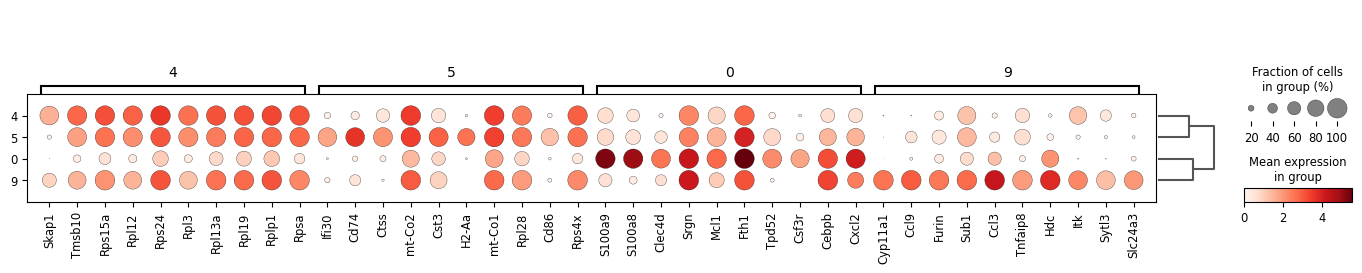

In [17]:
sc.tl.rank_genes_groups(
    adata_leukocytes,
    groupby="leiden",
    method="wilcoxon",
    use_raw=False,
)

sc.pl.rank_genes_groups_dotplot(
    adata_leukocytes,
    n_genes=10,
    groupby="leiden",
    standard_scale=None,
)

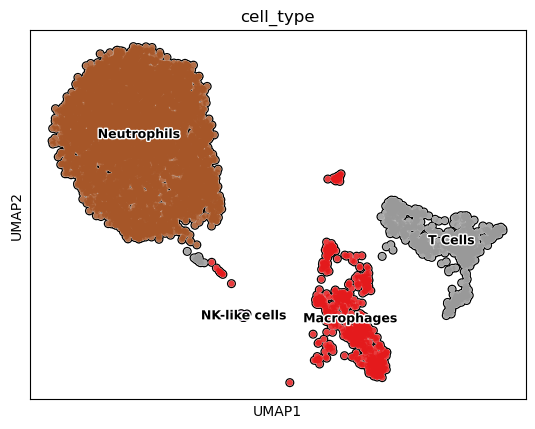

In [18]:
cluster_labels = {
    "0": "Neutrophils", #
    "4": "T Cells", # 
    "5": "Macrophages", # 
    "9": "NK-like cells"
}

adata_leukocytes.obs["cell_type"] = (
    adata_leukocytes.obs["leiden"]
    .astype(str)
    .map(cluster_labels)
    .fillna("Unassigned")
    .astype("category")
)

sc.pl.umap(
    adata_leukocytes,
    color=["cell_type"],
    **UMAP_STYLE
)

Proportion of macrophages

In [19]:
n_macrophages = (
    adata_leukocytes.obs["cell_type"] == "Macrophages"
).sum()

n_leukocytes = adata_leukocytes.n_obs

macrophage_percentage = 100 * n_macrophages / n_leukocytes

print(f"Macrophages: {n_macrophages}")
print(f"Total leukocytes: {n_leukocytes}")
print(f"Macrophage percentage: {macrophage_percentage:.2f}%")

Macrophages: 531
Total leukocytes: 5816
Macrophage percentage: 9.13%


Calculating immune cell proportions in leukocytes

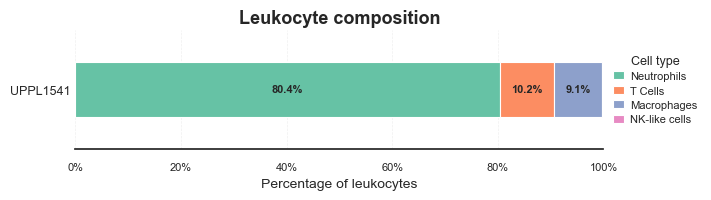

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = (
    adata_leukocytes.obs["cell_type"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
    .to_frame()
    .T
)

plot_data.index = ["UPPL1541"]

sns.set_theme(style="white", context="notebook")

colors = sns.color_palette("Set2", n_colors=plot_data.shape[1])

fig, ax = plt.subplots(figsize=(8, 2.2))

plot_data.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=colors,
    width=0.42,
    edgecolor="white",
    linewidth=0.8,
)

for container in ax.containers:
    labels = [
        f"{bar.get_width():.1f}%"
        if bar.get_width() >= 4
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8,
        fontweight="semibold",
    )

ax.set_title(
    "Leukocyte composition",
    fontsize=13,
    fontweight="bold",
    pad=5,
)

ax.set_xlabel("Percentage of leukocytes", fontsize=10, labelpad=4)
ax.set_ylabel("")
ax.set_xlim(0, 100)

ax.set_xticks(range(0, 101, 20))
ax.set_xticklabels(
    [f"{x}%" for x in range(0, 101, 20)],
    fontsize=8,
)

ax.tick_params(axis="y", labelsize=9, length=0)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.3)

ax.legend(
    title="Cell type",
    bbox_to_anchor=(1.01, 0.5),
    loc="center left",
    frameon=False,
    fontsize=8,
    title_fontsize=9,
    handlelength=1,
    handletextpad=0.5,
    labelspacing=0.4,
    borderaxespad=0,
)

fig.subplots_adjust(
    left=0.12,
    right=0.78,
    top=0.82,
    bottom=0.28,
)

plt.savefig(
    output_dir / "UPPL1541_leukocyte_composition.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()